In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from PIL import Image
import copy

# openpi imports
from openpi.training import config as _config
from openpi.policies import policy_config as _policy_config
from openpi.policies import aloha_policy
from openpi.shared import download
from openpi import transforms as _transforms
from openpi.shared import normalize as _normalize

print("Imports OK")

Imports OK


In [2]:
joint_labels = [
    "L joint 0 (waist)", "L joint 1 (shoulder)", "L joint 2 (elbow)",
    "L joint 3 (forearm)", "L joint 4 (wrist angle)", "L joint 5 (wrist rotate)",
    "L gripper",
    "R joint 0 (waist)", "R joint 1 (shoulder)", "R joint 2 (elbow)",
    "R joint 3 (forearm)", "R joint 4 (wrist angle)", "R joint 5 (wrist rotate)",
    "R gripper",
]

In [3]:
def frame_to_obs(frame):
    """Convert a HuggingFace dataset frame to the observation dict
    that the policy expects (post-RepackTransform format)."""
    def to_chw(img):
        arr = np.array(img)  # PIL → HWC (H, W, 3)
        return arr.transpose(2, 0, 1)  # → CHW (3, H, W)
    
    return {
        "images": {
            "cam_high": to_chw(frame["observation.images.cam_high"]),
            "cam_left_wrist": to_chw(frame["observation.images.cam_left_wrist"]),
            "cam_right_wrist": to_chw(frame["observation.images.cam_right_wrist"]),
        },
        "state": np.array(frame["observation.state"]),
        "prompt": "uncap the pen",
    }

In [4]:
ds = load_dataset("physical-intelligence/aloha_pen_uncap_diverse", split="train")
print(f"Total rows: {len(ds)}")
print(f"Columns: {ds.column_names}")
print(f"Episode indices: {sorted(set(ds['episode_index']))}")

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/123 [00:00<?, ?it/s]

Total rows: 36900
Columns: ['observation.state', 'action', 'observation.velocity', 'observation.effort', 'observation.images.cam_high', 'observation.images.cam_low', 'observation.images.cam_left_wrist', 'observation.images.cam_right_wrist', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']
Episode indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122]


In [5]:
# Pick an episode and grab all its frames
EPISODE_IDX = 0

ep_indices = np.array(ds["episode_index"])
mask = ep_indices == EPISODE_IDX
row_indices = np.where(mask)[0]
episode = ds.select(row_indices)

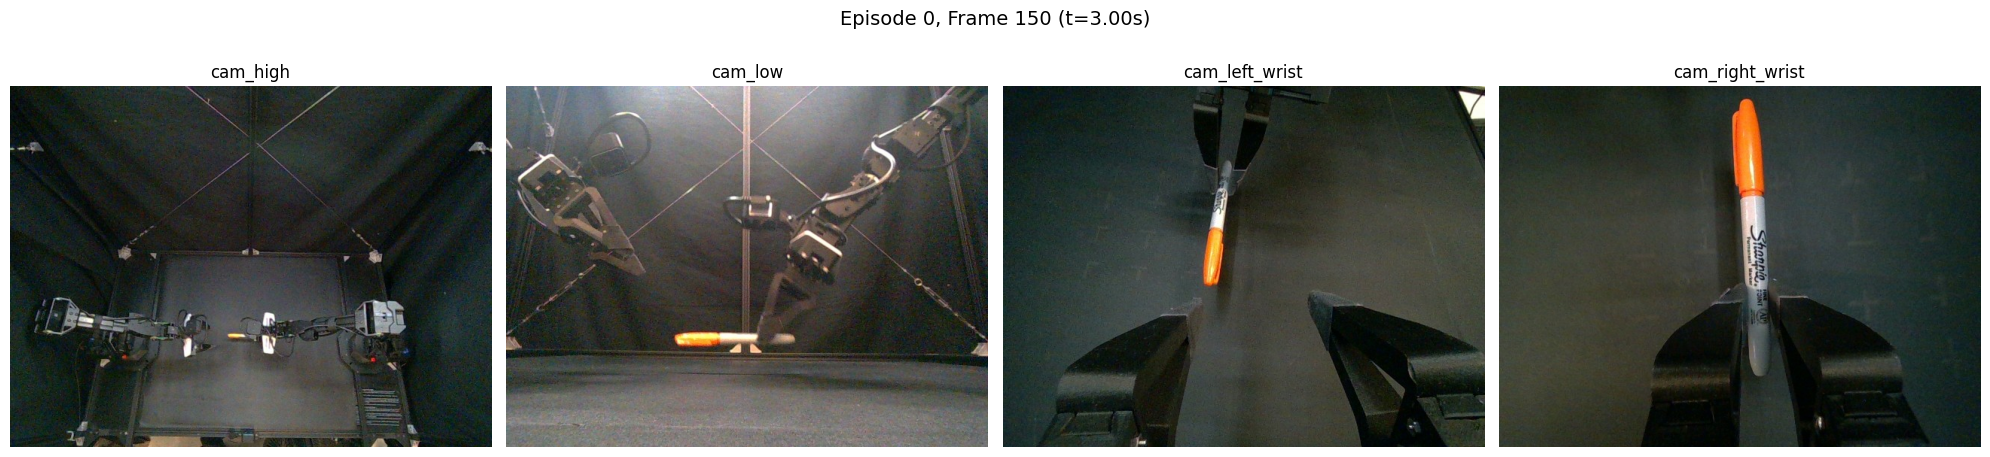

In [6]:
# Pick a frame in the middle of the episode — interesting stuff is happening here
FRAME_IDX = 150
frame = episode[FRAME_IDX]

# Display the 4 camera views
cam_names = ["cam_high", "cam_low", "cam_left_wrist", "cam_right_wrist"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, cam_names):
    img = frame[f"observation.images.{name}"]
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle(f"Episode {EPISODE_IDX}, Frame {FRAME_IDX} (t={frame['timestamp']:.2f}s)", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
config = _config.get_config("pi0_aloha_pen_uncap")
checkpoint_dir = download.maybe_download("gs://openpi-assets/checkpoints/pi0_aloha_pen_uncap")

print(f"Model type: {config.model.model_type}")
print(f"Action dim: {config.model.action_dim}")
print(f"Action horizon: {config.model.action_horizon}")
print(f"Checkpoint: {checkpoint_dir}")

Model type: ModelType.PI0
Action dim: 32
Action horizon: 50
Checkpoint: /home/stephen/.cache/openpi/openpi-assets/checkpoints/pi0_aloha_pen_uncap


In [8]:
policy = _policy_config.create_trained_policy(config, checkpoint_dir)
print("Policy created successfully!")
print(f"Number of input transforms: {len(policy._input_transform.transforms)}")
print(f"Number of output transforms: {len(policy._output_transform.transforms)}")

Policy created successfully!
Number of input transforms: 8
Number of output transforms: 3


In [9]:
# Run inference on a single frame
obs_for_infer = frame_to_obs(frame)
result = policy.infer(obs_for_infer)
predicted_actions = result["actions"]

In [10]:
from openpi.models import model as _model
import time
import jax
import jax.numpy as jnp
import einops

In [11]:
# === Fix noise for reproducibility ===
fixed_noise = np.array(jax.random.normal(jax.random.key(42), (50, 32)))

In [12]:
fixed_noise.shape

(50, 32)

In [13]:
# === Reference result (using policy.infer as a black box) ===
obs_ref = frame_to_obs(frame)
result_ref = policy.infer(obs_ref, noise=fixed_noise)

In [15]:
result_ref.keys()

dict_keys(['actions', 'policy_timing'])

In [17]:
result_ref['actions'].shape

(50, 14)

In [18]:
# === Manual reproduction of policy.infer() ===
obs_manual = frame_to_obs(frame)

In [19]:
obs_manual.keys()

dict_keys(['images', 'state', 'prompt'])

In [20]:
# 1. Input transforms (the full chain we traced in Section 5)
inputs = policy._input_transform(obs_manual)

In [22]:
inputs.keys()

dict_keys(['image', 'image_mask', 'state', 'tokenized_prompt', 'tokenized_prompt_mask'])

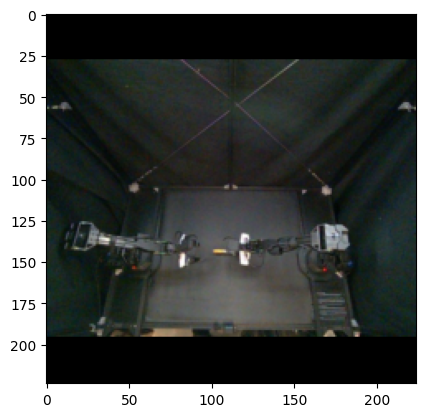

In [27]:
plt.imshow(inputs['image']['base_0_rgb'])

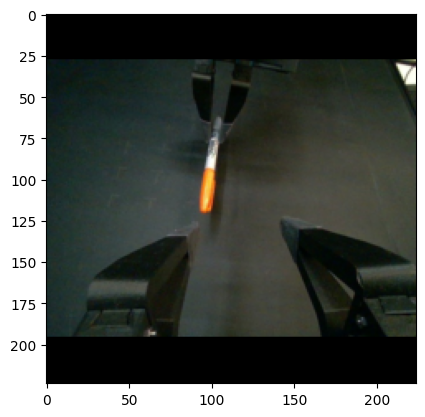

In [28]:
plt.imshow(inputs['image']['left_wrist_0_rgb'])

In [ ]:
inputs['image']['right_wrist_0_rgb']

In [29]:
inputs['image_mask']

{'base_0_rgb': True, 'left_wrist_0_rgb': True, 'right_wrist_0_rgb': True}

In [30]:
inputs['state']

array([-0.20725932, -0.00501022, -0.80655044, -0.61167286, -1.26388371,
        0.49682481,  0.70461937, -0.11850004, -0.7430179 , -0.04984882,
        0.06776268, -0.8377513 , -0.40270402, -1.2744017 ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ])

In [31]:
inputs['tokenized_prompt']

array([   2,  549, 5549,  573, 3008,  108,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0])

In [32]:
inputs['tokenized_prompt_mask']

array([ True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [33]:
# 2. Batch and convert to JAX arrays: each leaf [shape] → jnp [1, shape]
inputs = jax.tree.map(lambda x: jnp.asarray(x)[np.newaxis, ...], inputs)

In [35]:
# inputs

In [38]:
# 3. Build Observation dataclass (also converts uint8 images → float32 in [-1, 1])
observation = _model.Observation.from_dict(inputs)

In [42]:
# observation

In [43]:
# 4. Call sample_actions — the model forward pass + flow matching loop
#    When noise is provided, the rng is unused
noise_batched = jnp.asarray(fixed_noise)[None, ...]  # [1, 50, 32]
start = time.monotonic()

In [44]:
# raw_actions = policy._sample_actions(
#     jax.random.key(0),  # ignored when noise is provided
#     observation,
#     noise=noise_batched,
# )

# === Expand sample_actions into explicit steps ===

model = policy._model
num_steps = 10
dt = -1.0 / num_steps

In [45]:
# --- Preprocess observation (no-op at inference: no augmentation, no resizing needed) ---
observation = _model.preprocess_observation(None, observation, train=False)

# --- Embed prefix: SigLIP encodes images, PaliGemma embeds language tokens ---
prefix_tokens, prefix_mask, prefix_ar_mask = model.embed_prefix(observation)
# print(f"prefix_tokens: {prefix_tokens.shape}")   # [1, 816, 2048] = 3×256 image + 48 language
# print(f"prefix_mask: {prefix_mask.shape}")         # [1, 816]
# print(f"prefix_ar_mask: {prefix_ar_mask.shape}")   # [816]

In [46]:
prefix_tokens.shape

(1, 816, 2048)

In [47]:
prefix_mask.shape

(1, 816)

Are images broken into 256 patches each? Is that the deal?

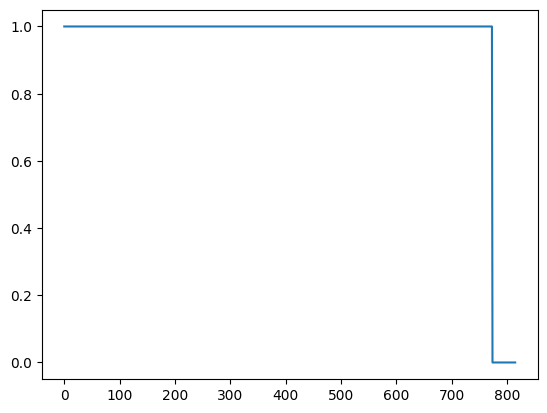

In [50]:
plt.plot(prefix_mask.ravel())

In [51]:
np.sum(prefix_mask)

Array(774, dtype=int32)

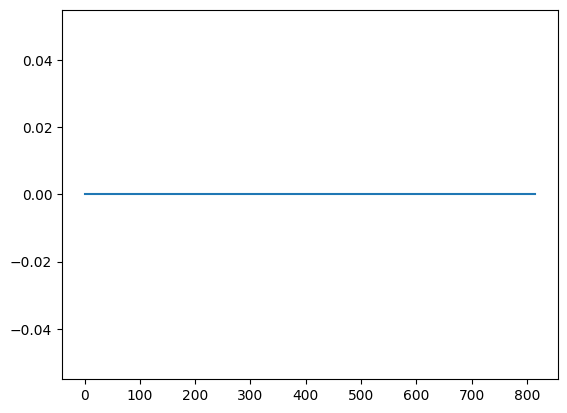

In [53]:
plt.plot(prefix_ar_mask)

In [56]:
# === Expand embed_prefix: SigLIP image encoding + language embedding ===

tokens_list = []
input_mask_list = []
ar_mask_list = []

# --- Encode each image through SigLIP (So400m/14) ---
# 224×224 image → 14×14 grid of 16×16 patches → 256 tokens, projected to PaliGemma dim=2048
for name in observation.images:
    image = observation.images[name]

    #Ok so this is like CLIP, passes through a 27 layer transformer - got it - interesting!
    image_tokens, siglip_extras = model.PaliGemma.img(image, train=False)
    
    print(f"SigLIP({name}):")
    print(f"  input:  {image.shape}, dtype={image.dtype}, range=[{image.min():.2f}, {image.max():.2f}]")
    print(f"  output: {image_tokens.shape}, dtype={image_tokens.dtype}")
    
    tokens_list.append(image_tokens)
    input_mask_list.append(
        einops.repeat(observation.image_masks[name], "b -> b s", s=image_tokens.shape[1])
    )
    ar_mask_list += [False] * image_tokens.shape[1]

SigLIP(base_0_rgb):
  input:  (1, 224, 224, 3), dtype=float32, range=[-1.00, 0.99]
  output: (1, 256, 2048), dtype=bfloat16
SigLIP(left_wrist_0_rgb):
  input:  (1, 224, 224, 3), dtype=float32, range=[-1.00, 1.00]
  output: (1, 256, 2048), dtype=bfloat16
SigLIP(right_wrist_0_rgb):
  input:  (1, 224, 224, 3), dtype=float32, range=[-1.00, 1.00]
  output: (1, 256, 2048), dtype=bfloat16


In [63]:
# plt.plot(ar_mask_list)

In [64]:
# tokens_list

In [65]:
# --- Embed language tokens through PaliGemma's Gemma embedder ---
# Token IDs → lookup in embedding table (vocab_size=257152, dim=2048) → scale by sqrt(2048)
tokenized_inputs = model.PaliGemma.llm(observation.tokenized_prompt, method="embed")
print(f"\nLanguage embedding:")
print(f"  token IDs:  {observation.tokenized_prompt.shape}, non-padding: {observation.tokenized_prompt_mask.sum()}")
print(f"  embeddings: {tokenized_inputs.shape}, dtype={tokenized_inputs.dtype}")


Language embedding:
  token IDs:  (1, 48), non-padding: 6
  embeddings: (1, 48, 2048), dtype=bfloat16


In [66]:
tokens_list.append(tokenized_inputs)
input_mask_list.append(observation.tokenized_prompt_mask)
ar_mask_list += [False] * tokenized_inputs.shape[1]

In [68]:
len(tokens_list)

4

In [70]:
# input_mask_list

In [72]:
# --- Concatenate into the full prefix sequence ---
prefix_tokens_manual = jnp.concatenate(tokens_list, axis=1)
prefix_mask_manual = jnp.concatenate(input_mask_list, axis=1)
prefix_ar_mask_manual = jnp.array(ar_mask_list)


print(f"\nFull prefix:")
print(f"  tokens:  {prefix_tokens_manual.shape}  (3×256 image + 48 language = 816)")
print(f"  mask:    {prefix_mask_manual.shape}  (valid tokens: {prefix_mask_manual.sum()})")
print(f"  ar_mask: {prefix_ar_mask_manual.shape}  (all False = fully bidirectional)")



Full prefix:
  tokens:  (1, 816, 2048)  (3×256 image + 48 language = 816)
  mask:    (1, 816)  (valid tokens: 774)
  ar_mask: (816,)  (all False = fully bidirectional)


In [73]:
# --- Compare against reference ---
max_diff = np.max(np.abs(np.asarray(prefix_tokens_manual) - np.asarray(prefix_tokens)))
print(f"\nMax diff vs reference embed_prefix: {max_diff}")

## Ok I think this makes sense up to here
## Images go through basically the image encoder of clip, language tokens just go through a 
## standard LLM embedding. I'm a bit fuzzy on the masks, that should become more clear I think!
## Reading the papers again after this will be interseting


Max diff vs reference embed_prefix: 0


In [74]:
# --- Prefix forward pass: run PaliGemma through all 18 layers, cache KV ---
from openpi.models.pi0 import make_attn_mask

prefix_attn_mask = make_attn_mask(prefix_mask, prefix_ar_mask)
positions = jnp.cumsum(prefix_mask, axis=1) - 1
print(f"prefix_attn_mask: {prefix_attn_mask.shape}")  # [1, 816, 816]
print(f"positions: {positions.shape}")                  # [1, 816]

prefix_attn_mask: (1, 816, 816)
positions: (1, 816)


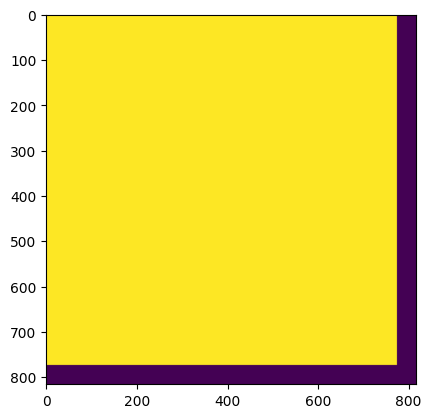

In [76]:
plt.imshow(prefix_attn_mask[0])

In [78]:
# positions

In [79]:
# Woah this way of merging models is kinda nuts! I haven't seen this before - pretty wild. 
# Could be cool to explain this as well as we can in the video

_, kv_cache = model.PaliGemma.llm(
    [prefix_tokens, None],  # only PaliGemma expert runs; action expert gets None
    mask=prefix_attn_mask,
    positions=positions,
)
cache_k, cache_v = kv_cache
print(f"KV cache K: {cache_k.shape}")  # [18, 1, 816, num_kv_heads, head_dim]
print(f"KV cache V: {cache_v.shape}")

KV cache K: (18, 1, 816, 1, 256)
KV cache V: (18, 1, 816, 1, 256)


- Where was I reading about this? Things come together in the MLP layers or attention or both or something?
- Ok yeah I think basic pieces are here - probably most complicated things will be making sense of the two experts. 

In [11]:


# --- Flow matching denoising loop: 10 Euler steps from t=1 (noise) to t=0 (actions) ---

batch_size = observation.state.shape[0]
x_t = noise_batched  # [1, 50, 32] — start from fixed noise

# Collect trajectory for later visualization
trajectory = [np.asarray(x_t[0])]  # store x_t at each step
velocities = []                     # store v_t at each step
t = 1.0

for step in range(num_steps):
    # Embed suffix: state token + action/time tokens
    suffix_tokens, suffix_mask, suffix_ar_mask, adarms_cond = model.embed_suffix(
        observation, x_t, jnp.broadcast_to(t, batch_size)
    )
    if step == 0:
        print(f"\nsuffix_tokens: {suffix_tokens.shape}")  # [1, 51, 1024] = 1 state + 50 action
        print(f"suffix_mask: {suffix_mask.shape}")
        print(f"suffix_ar_mask: {suffix_ar_mask.shape}")
        print(f"adarms_cond: {adarms_cond}")  # None for pi0

    # Build attention mask: suffix queries attend to [prefix KV cache | suffix tokens]
    suffix_attn_mask = make_attn_mask(suffix_mask, suffix_ar_mask)
    prefix_cross_mask = einops.repeat(prefix_mask, "b p -> b s p", s=suffix_tokens.shape[1])
    full_attn_mask = jnp.concatenate([prefix_cross_mask, suffix_attn_mask], axis=-1)
    if step == 0:
        print(f"full_attn_mask: {full_attn_mask.shape}")  # [1, 51, 816+51]

    # Suffix positions continue from where prefix left off
    suffix_positions = jnp.sum(prefix_mask, axis=-1)[:, None] + jnp.cumsum(suffix_mask, axis=-1) - 1

    # Forward pass: action expert runs on suffix, using cached prefix KV
    (prefix_out, suffix_out), _ = model.PaliGemma.llm(
        [None, suffix_tokens],           # PaliGemma expert skipped; action expert runs
        mask=full_attn_mask,
        positions=suffix_positions,
        kv_cache=kv_cache,
        adarms_cond=[None, adarms_cond],  # no adaRMS for pi0
    )
    assert prefix_out is None

    # Extract velocity from last 50 tokens (the action tokens, excluding state token)
    v_t = model.action_out_proj(suffix_out[:, -model.action_horizon:])
    if step == 0:
        print(f"\nv_t (velocity): {v_t.shape}")  # [1, 50, 32]

    # Euler step
    x_t = x_t + dt * v_t
    t = t + dt

    trajectory.append(np.asarray(x_t[0]))
    velocities.append(np.asarray(v_t[0]))
    print(f"  step {step}: t={t+dt:.1f}→{t:.1f}, |v_t|={np.linalg.norm(np.asarray(v_t)):.2f}, |x_t|={np.linalg.norm(np.asarray(x_t)):.2f}")

# --- Compare against reference ---
# Apply the same output transforms to our manually denoised actions
outputs_manual2 = {
    "state": np.asarray(inputs["state"][0]),
    "actions": np.asarray(x_t[0]),
}
outputs_manual2 = policy._output_transform(outputs_manual2)

max_diff = np.max(np.abs(result_ref["actions"] - outputs_manual2["actions"]))
print(f"\nMax diff vs reference: {max_diff:.2e}")
print(f"All close (atol=1e-5): {np.allclose(result_ref['actions'], outputs_manual2['actions'], atol=1e-5)}")

SigLIP(base_0_rgb):
  input:  (1, 224, 224, 3), dtype=float32, range=[-1.00, 0.99]
  output: (1, 256, 2048), dtype=bfloat16
SigLIP(left_wrist_0_rgb):
  input:  (1, 224, 224, 3), dtype=float32, range=[-1.00, 1.00]
  output: (1, 256, 2048), dtype=bfloat16
SigLIP(right_wrist_0_rgb):
  input:  (1, 224, 224, 3), dtype=float32, range=[-1.00, 1.00]
  output: (1, 256, 2048), dtype=bfloat16

Language embedding:
  token IDs:  (1, 48), non-padding: 6
  embeddings: (1, 48, 2048), dtype=bfloat16

Full prefix:
  tokens:  (1, 816, 2048)  (3×256 image + 48 language = 816)
  mask:    (1, 816)  (valid tokens: 774)
  ar_mask: (816,)  (all False = fully bidirectional)

Max diff vs reference embed_prefix: 0
prefix_attn_mask: (1, 816, 816)
positions: (1, 816)
KV cache K: (18, 1, 816, 1, 256)
KV cache V: (18, 1, 816, 1, 256)

suffix_tokens: (1, 51, 1024)
suffix_mask: (1, 51)
suffix_ar_mask: (51,)
adarms_cond: None
full_attn_mask: (1, 51, 867)

v_t (velocity): (1, 50, 32)
  step 0: t=0.8→0.9, |v_t|=41.36, |x_

In [12]:
# predicted_actions=outputs["actions"]
predicted_actions=outputs_manual2["actions"]

In [13]:
# Gather ground truth actions for the next action_horizon frames
action_horizon = predicted_actions.shape[0]
n_gt = min(action_horizon, len(episode) - FRAME_IDX)

gt_actions = np.array([episode[FRAME_IDX + t]["action"] for t in range(n_gt)])

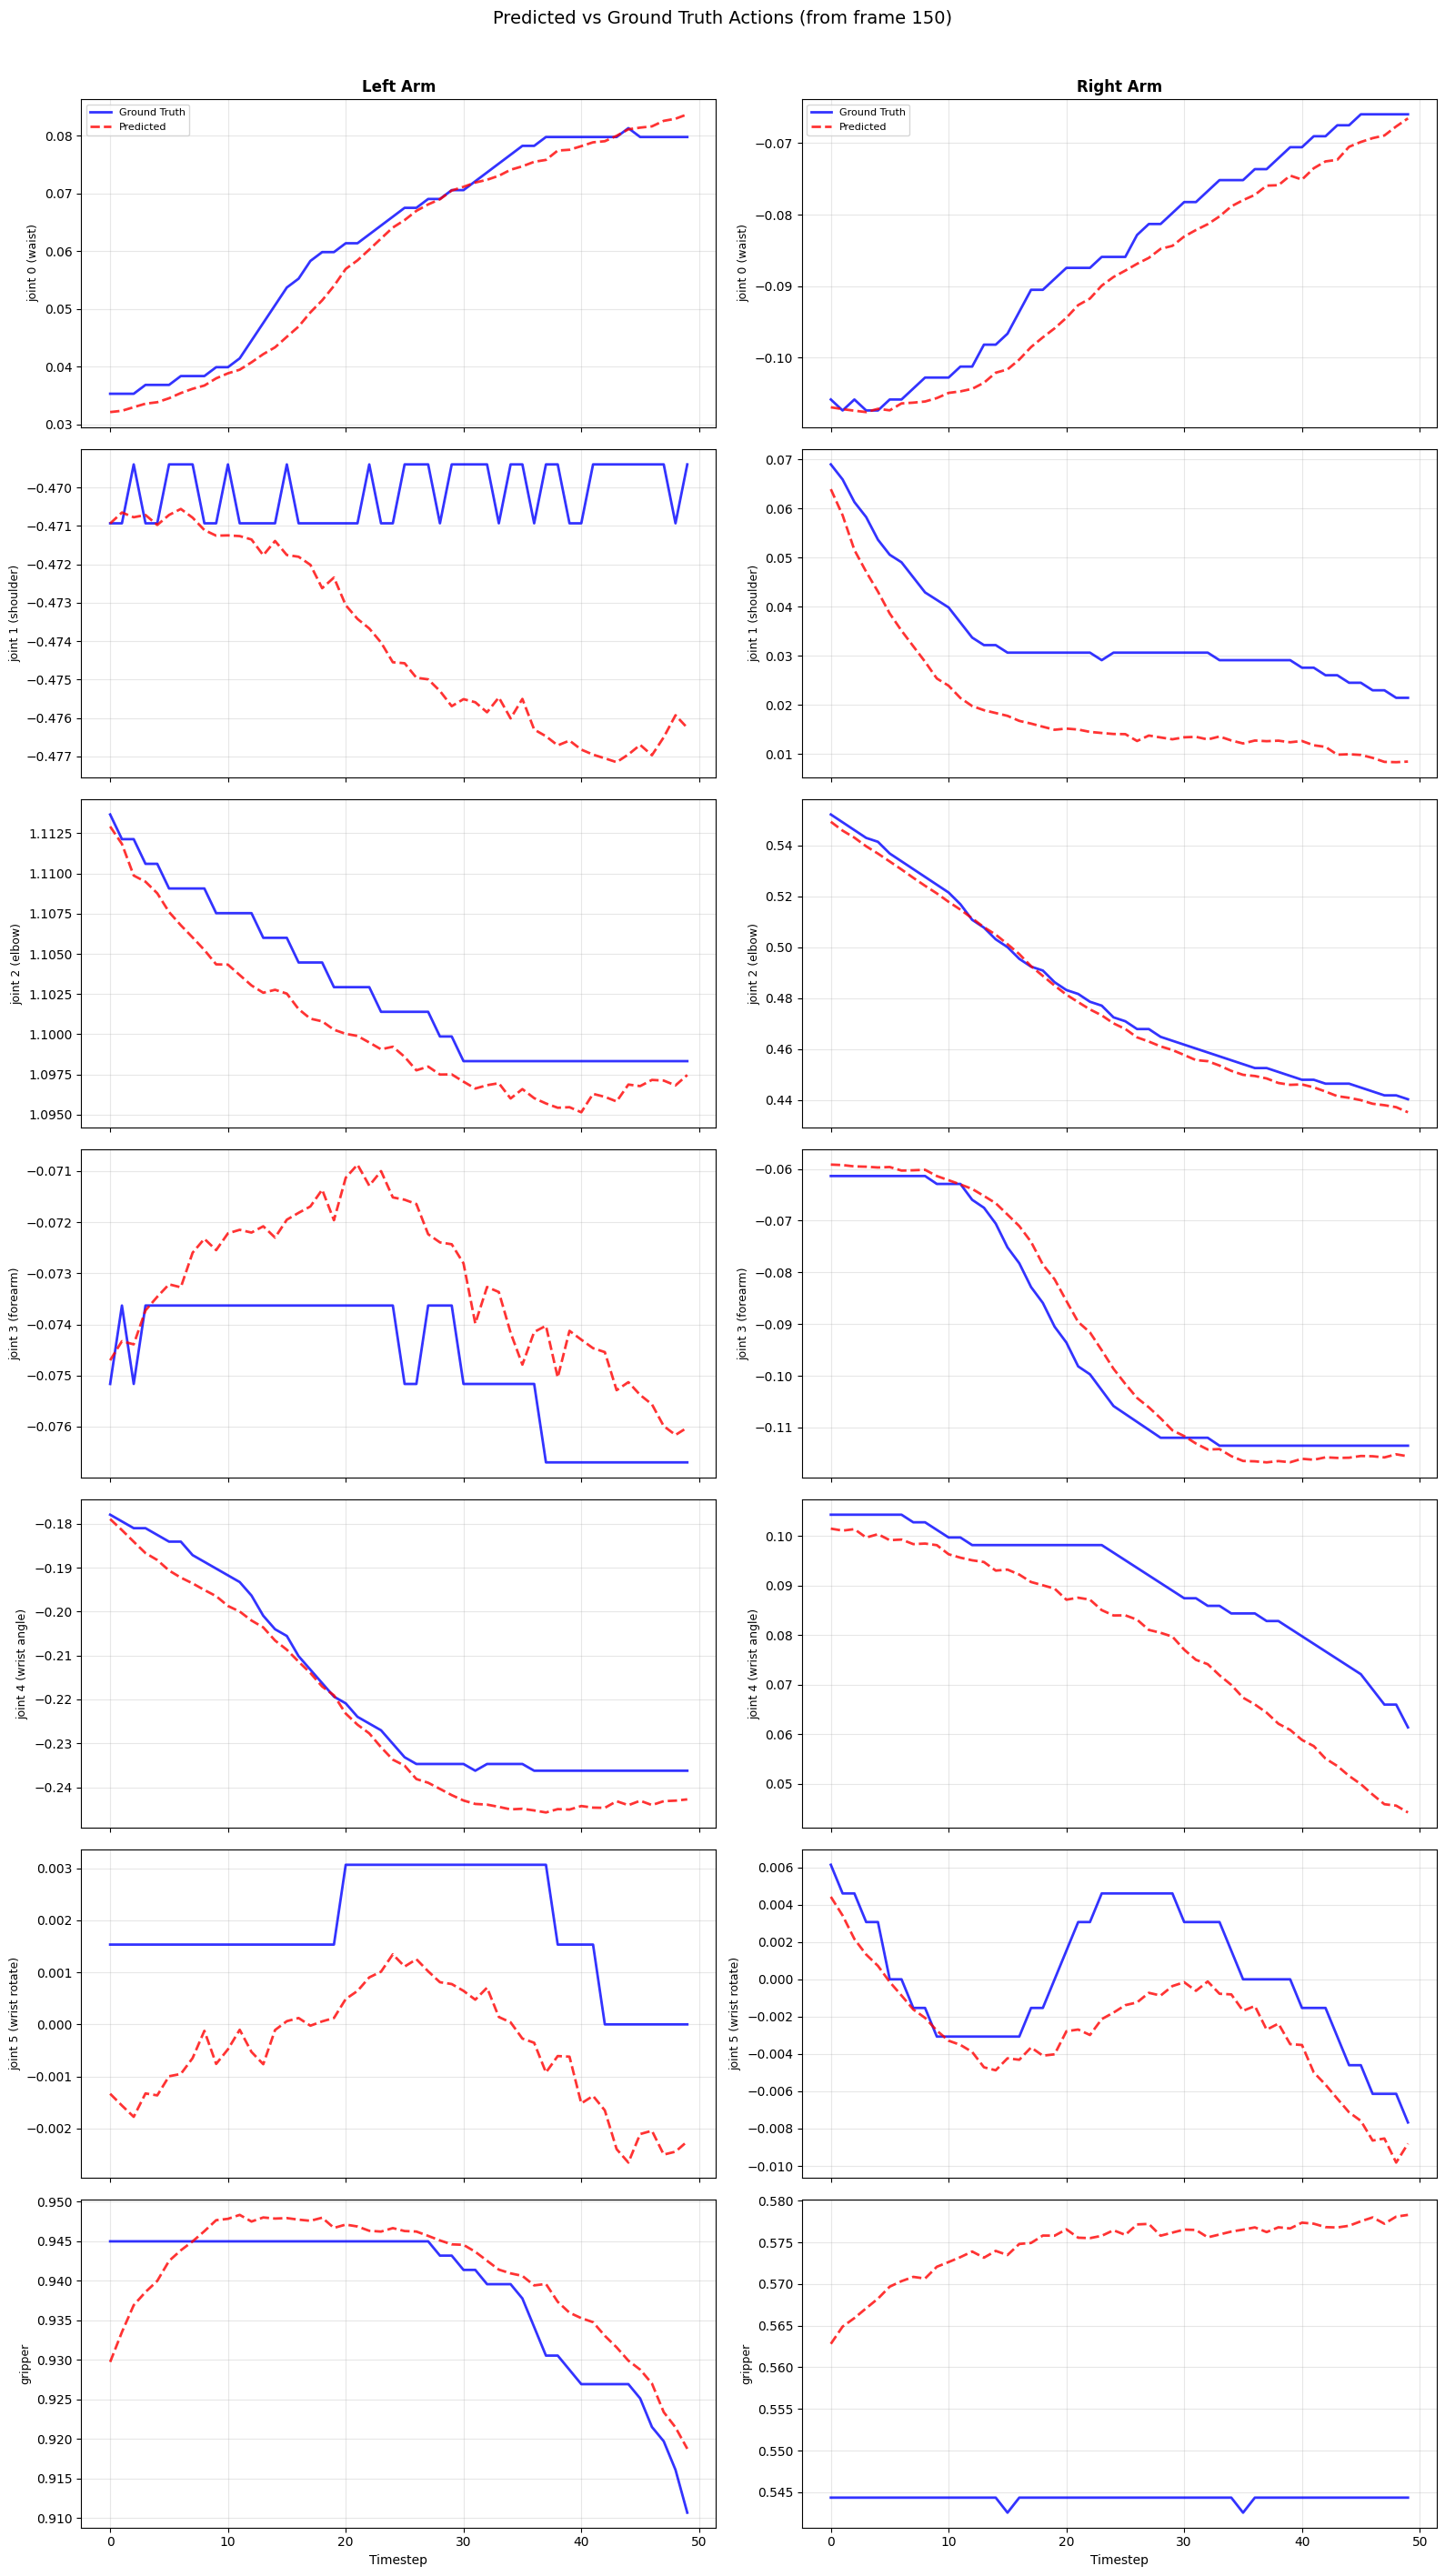

In [14]:
# Plot predicted vs ground truth for each joint
fig, axes = plt.subplots(7, 2, figsize=(16, 28), sharex=True)
time_steps = np.arange(n_gt)

for arm_idx, arm_name in enumerate(["Left", "Right"]):
    offset = arm_idx * 7
    for joint_idx in range(7):
        ax = axes[joint_idx, arm_idx]
        dim = offset + joint_idx
        
        ax.plot(time_steps, gt_actions[:n_gt, dim], 'b-', linewidth=2, label='Ground Truth', alpha=0.8)
        ax.plot(time_steps, predicted_actions[:n_gt, dim], 'r--', linewidth=2, label='Predicted', alpha=0.8)
        
        ax.set_ylabel(joint_labels[dim].replace(f"{arm_name[0]} ", ""), fontsize=9)
        ax.grid(True, alpha=0.3)
        if joint_idx == 0:
            ax.set_title(f"{arm_name} Arm", fontsize=12, fontweight='bold')
            ax.legend(fontsize=8)
        if joint_idx == 6:
            ax.set_xlabel("Timestep")

plt.suptitle(f"Predicted vs Ground Truth Actions (from frame {FRAME_IDX})", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()